# Actividad: Overfitting, Underfitting y Validación Cruzada

**Nombre(s):** *Erandi Shirel Miranda Barajas & David Leonardo García Hernández*

**Instrucciones:** Completa las secciones marcadas con `# COMPLETAR`. Ejecuta todas las celdas y responde las preguntas en los espacios provistos.

## 1. Importar librerías (código completo)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, validation_curve
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

## 2. Ejercicio 1: Underfitting vs Overfitting con polinomios

Ejecuta la siguiente celda. Luego **cambia el grado del polinomio** (variable `grado`) a los valores 1, 3 y 15. Observa las gráficas y responde.

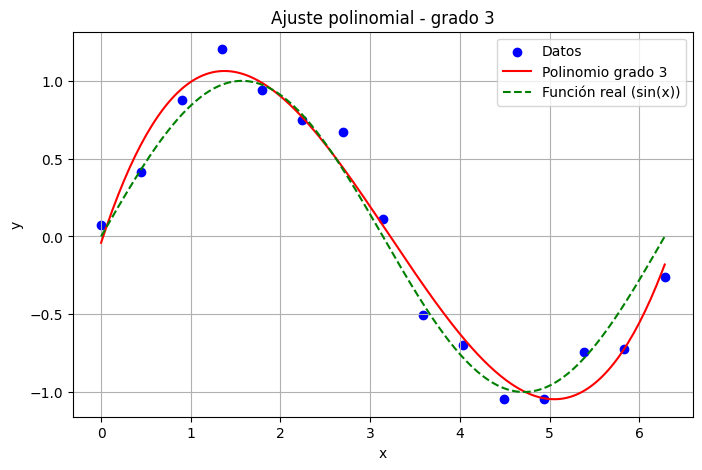

In [2]:
# Generar datos sintéticos
n = 15
x = np.linspace(0, 2*np.pi, n)
y = np.sin(x) + np.random.normal(0, 0.15, n)

# COMPLETAR: Cambia el grado del polinomio aquí
grado = 3   # Prueba con 1, 3 y 15

poly = PolynomialFeatures(degree=grado)
X_poly = poly.fit_transform(x.reshape(-1,1))
modelo = LinearRegression()
modelo.fit(X_poly, y)

# Visualizar
x_fino = np.linspace(0, 2*np.pi, 200)
X_fino_poly = poly.transform(x_fino.reshape(-1,1))
y_pred = modelo.predict(X_fino_poly)

plt.figure(figsize = (8,5))
plt.scatter(x, y, color='blue', label='Datos')
plt.plot(x_fino, y_pred, 'r-', label = f'Polinomio grado {grado}')
plt.plot(x_fino, np.sin(x_fino), 'g--', label = 'Función real (sin(x))')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Ajuste polinomial - grado {grado}')
plt.legend()
plt.grid(True)
plt.show()

### Pregunta 1

**a)** Con grado = 1, el modelo tiene *alto sesgo* (alto/bajo) y *baja* varianza* (alta/baja). Esto se llama *Underfitting.*

**b)** Con grado = 15, el modelo tiene *bajo sesgo* (alto/bajo) y *alta varianza* (alta/baja). Esto se llama *Overfitting.*

**c)** ¿Cuál de los tres grados (1, 3, 15) produce la curva que mejor aproxima a sin(x)? ¿Por qué?

**Respuesta:** *La curva con grado 3, porque los datos del polinomio grado 3 generan un equilibrio entre accuracy y recall.*



## 3. Ejercicio 2: Árbol de decisión y overfitting

El siguiente código entrena un árbol de decisión en el dataset de cáncer de mama. **Completa** la línea que falta y luego **cambia `max_depth`** a 1, 5, 10 y None (sin límite). Observa la diferencia entre entrenamiento y prueba.

In [3]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# COMPLETAR: Define un árbol con max_depth = 5 (cambia este valor)
arbol = DecisionTreeClassifier(max_depth = None, random_state = 42)

arbol.fit(X_train, y_train)
train_acc = arbol.score(X_train, y_train)
test_acc = arbol.score(X_test, y_test)

print(f"Precisión en entrenamiento: {train_acc:.4f}")
print(f"Precisión en prueba: {test_acc:.4f}")

Precisión en entrenamiento: 1.0000
Precisión en prueba: 0.9415


### Pregunta 2

**a)** Completa la tabla probando distintos valores de `max_depth`:

| max_depth | Precisión entrenamiento | Precisión prueba | ¿Overfitting? (Sí/No) |
|-----------|-------------------------|------------------|-----------------------|
| 1         | 0.9246                  | 0.8947           | No                    |
| 5         | 0.9950                  | 0.9532           | Sí           |
| 10        | 1.0000                  | 0.9415           | Sí                    |
| None      | 1.0000                  | 0.9415           | Sí                    |

**b)** ¿Qué profundidad elegirías para balancear sesgo y varianza? ¿Por qué?

**Respuesta:** *Se elegiría la max_depth = 5, ya que la precisión prueba es alta y la diferencia entre entrenamiento y prueba es baja, por ende el modelo generaliza mejor.*


## 4. Ejercicio 3: Validación cruzada (completar código)

Completa la función para que calcule la validación cruzada de un árbol de decisión con `max_depth=5` en el dataset de cáncer.

In [4]:
%%sql


UsageError: Cell magic `%%sql` not found.


In [ ]:
# COMPLETAR: Escribe el código que falta
arbol_cv = DecisionTreeClassifier(max_depth = 5, random_state = 42)

# Usa cross_val_score con cv=5
scores = cross_val_score(arbol_cv, X, y, cv=5, scoring='accuracy')

print("Exactitud por pliegue:", scores)
print(f"Exactitud media: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

Exactitud por pliegue: [0.89473684 0.9122807  0.92982456 0.94736842 0.91150442]
Exactitud media: 0.9191
Desviación estándar: 0.0180


### Pregunta 3

**a)** ¿Por qué es mejor reportar la media y desviación de la validación cruzada que una sola partición train/test?

**Respuesta:** *Porque la media representa el rendimiento promedio del modelo, mientras que la desviación representa la variabilidad del modelo.
En cambio, con una sola partición train/test, sólo se obtiene un número pero no se sabría si es correcto o no.*

**b)** Si la desviación estándar fuera muy alta (ej. 0.15), ¿qué significaría acerca del modelo?

**Respuesta:** Significa que el modelo es inestable y hay posibilidades de que su rendimiento varíe conforme cambien los datos.


## 5. Reflexión final

**Pregunta abierta:** En un problema médico (ej. diagnóstico de cáncer), ¿es preferible un modelo con un poco más de sesgo pero baja varianza, o uno con muy bajo sesgo pero alta varianza? Justifica tu respuesta pensando en las consecuencias clínicas.

**Respuesta:** ___________________________________________________________________
_________________________________________________________________________________
_________________________________________________________________________________

---
**¡Has terminado! Revisa tus respuestas y asegúrate de haber ejecutado todas las celdas.**